In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from data_simulations import *
import tqdm
import warnings
warnings.filterwarnings("ignore")
from shapely.geometry import Point, Polygon, LinearRing, LineString
import os

from data_simulations import (
    # New classes for tissue generation
    RegionSpec,
    TissueSlice,
    
    # Core simulation objects
    FOVDistribution,
    FOV,
    FrameWideElement,
    HistologicalElement,
    VacuolatedStructure,
    CellTypesProperties,
    TissueCellTypes,
    HybISS_Setup,
    
    # Rule classes
    ProbabilityNodeFieldRule,
    SingleTypeRule
)

In [ ]:
# 1) Define tissue & gene programs
tissue = TissueCellTypes()
tissue.generate_types_and_markers(
    n_genes=20, n_cell_types=6, expected_level=8.0, expected_std_level=3.0, concentration=0.9
)

# 2) Visual / biophysical props
props = CellTypesProperties(
    n_cell_types=tissue.n_cell_types,
    sizes=13, size_variation=1,
    anisotropy=0.85, anisotropy_variation=0.05,
    relative_rna_concentration=1.0, rna_concentration_variation=0.05,
)

# 3) Spatial scene
bg = FrameWideElement(
    frame_size=1000, tipical_cell_spacing=12,
    rules=[ProbabilityNodeFieldRule(n_cell_types=tissue.n_cell_types, n_ref_points=5, alpha=0.05)]
)
patches = [
    HistologicalElement(scale=300, n_vertices=(6,10),
        rules=[SingleTypeRule(n_cell_types=tissue.n_cell_types, cell_type_ix=i)])
    for i in (0,2,4)
]
fovd = FOVDistribution(frame_size=1000, background_element=bg,
                       other_elements=patches, elements_frequency=[0.8,0.6,0.5],
                       attempts_at_elements=2)

# 4) Assay model (two options)
hybISS = HybISS_Setup(
    tissue,
    genes_sensitivities=1.0, genes_sensitivities_variation=0.3,
    transfer_function=AffineNonNegTransfer(scales=1.0, scales_std=0.15, offsets=0.0, offsets_std=0.02)
)

# 5) Generate a dataset
generate_dataset("./sim_out", fovd, hybISS, tissue, props, n_samples=20)

100%|██████████| 20/20 [00:12<00:00,  1.62it/s]


In [4]:
!python visualize_benchmark.py sim_out --max-fovs 20 --ncols 5 --save-prefix s1 --point-size 5


=== sim_out ===
FOVs: 20 | Cells total: 159579
Cells/FOV: min=7968, median=7968, max=8187
Overall class distribution:
   0 (type_0              ): 48435 (30.4%)
   1 (type_1              ): 4284 (2.7%)
   2 (type_2              ): 35857 (22.5%)
   3 (type_3              ): 37167 (23.3%)
   4 (type_4              ): 26584 (16.7%)
   5 (type_5              ): 7252 (4.5%)
Saved s1_01.png
Saved s1_02.png
Figure(2000x1600)
Figure(500x200)


### Updated

In [2]:
import numpy as np
from shapely.geometry import Polygon, LineString

GLOBAL_WIDTH = 700
GLOBAL_HEIGHT = 1200
FRAME_SIZE = max(GLOBAL_HEIGHT, GLOBAL_WIDTH)
N_CELL_TYPES = 10 # Total cell types

# --- Assumed Cell Type IDs ---
ID_EPI_A = 0      # Type 0 (Blue) - Crypts
ID_EPI_B = 1      # Type 1 (Light Blue) - Crypts
ID_IMMUNE_A = 2   # Type 2 (Green) - Dense Right Region
ID_STROMA = 3     # Type 3 (Orange) - Sparse Middle / Crypt-Left
ID_IMMUNE_B = 4   # Type 4 (Purple) - Middle Structures
ID_ENDOTHELIAL = 5 # Type 5 (Red) - Crypt-Right
# Other IDs (6, 7, 8, 9) are available for middle structures

# =========================================================================
#  NEW HELPER FUNCTION FOR WAVY POLYGONS
# =========================================================================
def make_wavy_poly(x_start, x_end, y_start, y_end, waviness=30, n_points=20):
    """Helper to make a polygon with wavy vertical edges."""
    # Left wavy edge
    y_left = np.linspace(y_start, y_end, n_points)
    x_left = np.random.normal(x_start, waviness/3, n_points)
    # Clip to be within bounds
    x_left = np.clip(x_left, x_start - waviness, x_start + waviness)
    left_edge = list(zip(x_left, y_left))
    
    # Right wavy edge
    y_right = np.linspace(y_end, y_start, n_points) # Go back up
    x_right = np.random.normal(x_end, waviness/3, n_points)
    # Clip to be within bounds
    x_right = np.clip(x_right, x_end - waviness, x_end + waviness)
    right_edge = list(zip(x_right, y_right))
    
    # Combine
    poly = Polygon(left_edge + right_edge)
    return poly.buffer(0) # Clean up self-intersections

In [3]:
# =========================================================================
#  RECIPE 1: THE CRYPT REGION (Left Side)
# =========================================================================
# Helper to create rules for a single crypt
def create_crypt_rules(n_cell_types, crypt_center, crypt_width):
    # Prob for left side of crypt (Epithelial Type A)
    prob_A = np.zeros(n_cell_types)
    prob_A[ID_EPI_A] = 1.0
    prob_A[ID_EPI_B] = 0.0
    
    # Prob for right side of crypt (Epithelial Type B)
    prob_B = np.zeros(n_cell_types)
    prob_B[ID_EPI_A] = 1.0
    prob_B[ID_EPI_B] = 0.0
    
    # --- NEW (FIX) ---
    # Create a 3rd probability for a "top" point, as a mix
    prob_C = (prob_A + prob_B) / 2.0 
    # --- END NEW ---
    
    ref_points = np.array([
        crypt_center + [-crypt_width/1.5, 0],  # Left point
        crypt_center + [crypt_width/1.5, 0],   # Right point
        # --- NEW (FIX) ---
        crypt_center + [0, crypt_width/1.5]    # Top point
        # --- END NEW ---
    ])
    
    # --- NEW (FIX) ---
    # Pass all 3 probabilities
    ref_probs = np.array([prob_A, prob_B, prob_C])
    # --- END NEW ---
    
    return [ProbabilityNodeFieldRule(n_cell_types,
                                     # --- NEW (FIX) ---
                                     n_ref_points=3, # Must be 3
                                     # --- END NEW ---
                                     ref_probs=ref_probs,
                                     reference_points=ref_points)]

# MODIFIED: 9-point gradient for the background
# We have 3 zones, each defined by 3 vertical points to create stable "walls" of color.

# Zone 1 (Left): Pure Orange (Type 3)
prob_band_1 = np.zeros(N_CELL_TYPES)
prob_band_1[ID_STROMA] = 0.9   # Type 3 (Orange)
prob_band_1[ID_ENDOTHELIAL] = 0.1 # Type 5 (Red)

# Zone 2 (In-between): Pure Red (Type 5)
prob_band_2 = np.zeros(N_CELL_TYPES)
prob_band_2[ID_ENDOTHELIAL] = 1.0 # Type 5 (Red)

# Zone 3 (Right): Mix of Red (T5) and Green (T2)
prob_band_3 = np.zeros(N_CELL_TYPES)
prob_band_3[ID_ENDOTHELIAL] = 0.3 # Type 5 (Red)
prob_band_3[ID_IMMUNE_A] = 0.7  # Type 2 (Green)

crypt_bg_rules = [
    ProbabilityNodeFieldRule(
        n_cell_types=N_CELL_TYPES,
        n_ref_points=9, # Now using 9 points
        # Define 3 vertical points for each of the 3 bands
        reference_points=np.array([
            # --- Band 1 (x=40) ---
            [40, GLOBAL_HEIGHT * 0.1],  
            [40, GLOBAL_HEIGHT * 0.5],
            [40, GLOBAL_HEIGHT * 0.9],
            # --- Band 2 (x=130) ---
            [130, GLOBAL_HEIGHT * 0.1], 
            [130, GLOBAL_HEIGHT * 0.5],
            [130, GLOBAL_HEIGHT * 0.9],
            # --- Band 3 (x=210) ---
            [210, GLOBAL_HEIGHT * 0.1], 
            [210, GLOBAL_HEIGHT * 0.5],
            [210, GLOBAL_HEIGHT * 0.9],
        ]),
        ref_probs=np.array([
            # --- Band 1 Probs ---
            prob_band_1,
            prob_band_1,
            prob_band_1,
            # --- Band 2 Probs ---
            prob_band_2,
            prob_band_2,
            prob_band_2,
            # --- Band 3 Probs ---
            prob_band_3,
            prob_band_3,
            prob_band_3,
        ])
    )
]

# MODIFIED: New prototype function that takes a pre-defined center
def create_specific_crypt(center_loc):
    """Creates one crypt at a specific location."""
    scale = np.random.uniform(80, 150)
    rules = create_crypt_rules(N_CELL_TYPES, center_loc, scale)
    
    return VacuolatedStructure(frame_size=FRAME_SIZE,
                               scale=scale,
                               fixed_center=center_loc, # Use the passed-in center
                               rules=rules,
                               tipical_cell_spacing=5, # Very dense
                               # MODIFIED: Use new hole_scale_factor range
                               hole_scale_factor=np.random.uniform(0.5, 0.8))

# MODIFIED: Generate the structured list of crypt prototypes
crypt_prototypes_list = []
n_crypts_per_line = 15

# --- Generate Y positions ---
# Y positions for the first line
y_positions_line1 = np.linspace(40, GLOBAL_HEIGHT - 40, n_crypts_per_line)
# Y positions for the second line, offset for a "zig-zag"
y_stagger = (y_positions_line1[1] - y_positions_line1[0]) / 2
y_positions_line2 = y_positions_line1 + y_stagger
# Remove the last one if it's too close to the edge
y_positions_line2 = y_positions_line2[y_positions_line2 < GLOBAL_HEIGHT - 40]


# --- Create Line 1 (x ~ 80) ---
for y_pos in y_positions_line1:
    # Add randomness to the pre-defined location
    center = np.array([np.random.normal(80, 10), y_pos + np.random.normal(0, 10)])
    # We must use 'lambda c=center: ...' to "capture" the center variable correctly
    crypt_prototypes_list.append(lambda c=center: create_specific_crypt(c))

# --- Create Line 2 (x ~ 180) ---
for y_pos in y_positions_line2:
    center = np.array([np.random.normal(180, 10), y_pos + np.random.normal(0, 10)])
    crypt_prototypes_list.append(lambda c=center: create_specific_crypt(c))

CryptBGPrototype = lambda: FrameWideElement(frame_size=FRAME_SIZE,
                                            tipical_cell_spacing=7, # Dense
                                            rules=crypt_bg_rules)

# The FOV Distribution (recipe) for the entire Crypt region
fovd_crypts = FOVDistribution(frame_size=FRAME_SIZE,
                            background_element=CryptBGPrototype,
                            other_elements=crypt_prototypes_list,
                            elements_frequency=[1.0] * len(crypt_prototypes_list), 
                            attempts_at_elements=1)

In [4]:
# =========================================================================
#  RECIPE 2: THE SPARSE REGION (Middle) - UPDATED
# =========================================================================

# --- Background: Still the sparse orange cells ---
sparse_stroma_rules = [SingleTypeRule(N_CELL_TYPES, cell_type_ix=ID_STROMA)]
SparseStromaPrototype = lambda: FrameWideElement(frame_size=FRAME_SIZE,
                                                 tipical_cell_spacing=20, # Very sparse
                                                 rules=sparse_stroma_rules)

# --- NEW: Prototypes for small, dense structures in the middle ---

# Prototype 1: Disturbed Purple Rings (like your image)
def VascProto1():
    center = np.array([np.random.uniform(250, 350), 
                       np.random.uniform(50, GLOBAL_HEIGHT - 50)])
    scale = np.random.uniform(40, 80)
    rules = [MixOfNCellTypesRule(N_CELL_TYPES, list_N=[4, 7, 8], proportions=[0.7, 0.15, 0.15])]
    return VacuolatedStructure(frame_size=FRAME_SIZE,
                               scale=scale,
                               fixed_center=center,
                               rules=rules,
                               tipical_cell_spacing=4, # Dense
                               hole_scale_factor=np.random.uniform(0.6, 0.85)) # Small/thin ring

# Prototype 2: Small Green Patches/Rings
def VascProto2():
    center = np.array([np.random.uniform(250, 350), 
                       np.random.uniform(50, GLOBAL_HEIGHT - 50)])
    scale = np.random.uniform(20, 50)
    rules = [MixOfNCellTypesRule(N_CELL_TYPES, list_N=[8, 9], proportions=[1.0, 0.0])]
    return VacuolatedStructure(frame_size=FRAME_SIZE,
                               scale=scale,
                               fixed_center=center,
                               rules=rules,
                               tipical_cell_spacing=5, # Dense
                               hole_scale_factor=np.random.uniform(0.3, 0.6)) # Smaller hole

# The FOV Distribution (recipe) for the entire Middle region
fovd_middle_sparse = FOVDistribution(frame_size=FRAME_SIZE,
                                     background_element=SparseStromaPrototype,
                                     # Add the new structures
                                     other_elements=[VascProto1, VascProto2],
                                     elements_frequency=[1.0, 1.0],
                                     attempts_at_elements=[8, 8]) # Add 6 purple, 8 green

In [5]:
# =========================================================================
#  RECIPE 3: THE DENSE GRADIENT REGION (Right) - UPDATED
# =========================================================================

# --- Background: A 70/30 mix (mostly Green) ---
dense_mix_rules = [
    MixOfNCellTypesRule(N_CELL_TYPES, 
                        list_N=[6, 7, 8], # Green, Orange, Purple
                        proportions=[0.7, 0.2, 0.1])
]

DenseMixPrototype = lambda: FrameWideElement(frame_size=FRAME_SIZE,
                                                  tipical_cell_spacing=8, # Very dense
                                                  rules=dense_mix_rules)

# --- NEW: Prototypes for small, structured patches ---
def RightPatchProto():
    center = np.array([np.random.uniform(380, GLOBAL_WIDTH - 30), 
                       np.random.uniform(50, GLOBAL_HEIGHT - 50)])
    scale = np.random.uniform(40, 80)
    # Rules for patches: dense Purple and Red
    rules = [MixOfNCellTypesRule(N_CELL_TYPES, list_N=[8, 9], proportions=[1.0, 0.0])]
    return HistologicalElement(frame_size=FRAME_SIZE,
                               scale=scale,
                               fixed_center=center,
                               rules=rules,
                               n_vertices=(5, 8),
                               tipical_cell_spacing=4) # Very dense

# The FOV Distribution (recipe) for the entire Right region
fovd_right_dense = FOVDistribution(frame_size=FRAME_SIZE,
                                   background_element=DenseMixPrototype,
                                   # Add the new patches
                                   other_elements=[RightPatchProto],
                                   elements_frequency=[0.70], # 80% chance to try
                                   attempts_at_elements=15) # Try to add 15 patches

In [6]:
# =========================================================================
#  REGION DEFINITIONS (MODIFIED with wavy boundaries)
# =========================================================================

# R1: The Crypt Layer (Left)
R1_Crypts_Poly = make_wavy_poly(
    x_start=0, x_end=240, 
    y_start=0, y_end=GLOBAL_HEIGHT, 
    waviness=100
)

# R2: The Sparse Middle
R2_Middle_Sparse_Poly = make_wavy_poly(
    x_start=240, x_end=350, 
    y_start=0, y_end=GLOBAL_HEIGHT, 
    waviness=120
)

# R3: The Dense Right
# R3_Right_Dense_Poly = make_wavy_poly(
#     x_start=560, x_end=GLOBAL_WIDTH, 
#     y_start=0, y_end=GLOBAL_HEIGHT, 
#     waviness=100
# )

# R3: The Dense Right
# MODIFICATION: Replaced wavy poly with a smooth parabolic curve
n_points_curve = 30 # Number of points to define the curve
y_coords = np.linspace(0, GLOBAL_HEIGHT, n_points_curve)

# Define the parabola: x = a(y - k)^2 + h
h = 320  # x-coordinate of the vertex (the "deepest" part of the curve)
k = GLOBAL_HEIGHT / 2  # y-coordinate of the vertex (the middle of the frame)
x_start_edge = 400 # x-coordinate where the curve starts at the top/bottom
a = (x_start_edge - h) / (0 - k)**2 # Calculate the 'a' coefficient

# Calculate the x coordinates for the left boundary
x_curve = a * (y_coords - k)**2 + h

# Add a tiny bit of random noise so it's not a perfect mathematical line
x_curve += np.random.normal(0, 10.0, n_points_curve)

# Create the list of points for the polygon
# 1. Start with the curved left boundary (top to bottom)
left_boundary_points = list(zip(x_curve, y_coords))

# 2. Add the other 3 corners of the frame
other_points = [
    (GLOBAL_WIDTH, GLOBAL_HEIGHT), # Bottom-right
    (GLOBAL_WIDTH, 0)              # Top-right
]

R3_Right_Dense_Poly = Polygon(left_boundary_points + other_points)


all_regions = []

# --- Priority 0: The Base Sparse Stroma (Middle) ---
all_regions.append(RegionSpec(
    name="MiddleSparse",
    polygon=R2_Middle_Sparse_Poly,
    fovdist=fovd_middle_sparse, # This recipe now includes the small structures
    priority=0,
    blend_band=20.0 
))

# --- Priority 1: The Dense Gradient (Right) ---
all_regions.append(RegionSpec(
    name="RightDense",
    polygon=R3_Right_Dense_Poly,
    fovdist=fovd_right_dense, # This recipe now includes the patches
    priority=1,
    blend_band=20.0
))

# --- Priority 2: The Crypt Layer (Left) ---
all_regions.append(RegionSpec(
    name="Crypts",
    polygon=R1_Crypts_Poly,
    fovdist=fovd_crypts,
    priority=2,
    blend_band=10.0
))

# --- Create the Tissue Slice ---
print("Creating tissue slice...")
tissue_slice = TissueSlice(frame_size=FRAME_SIZE, regions=all_regions)

Creating tissue slice...


In [101]:
SUMs = []
N_GENES = [10, 20, 30, 50, 100, 200, 300, 500, 1000]

for gene in N_GENES:
    tissue = TissueCellTypes()
    tissue.generate_types_and_markers(
        n_genes=gene,
        n_cell_types=N_CELL_TYPES, 
        expected_level=10.0, 
        expected_std_level=3.0
    )
    cell_type_df = tissue.make_pandas_df()
    SUMs.append(cell_type_df.values.sum(1).mean())

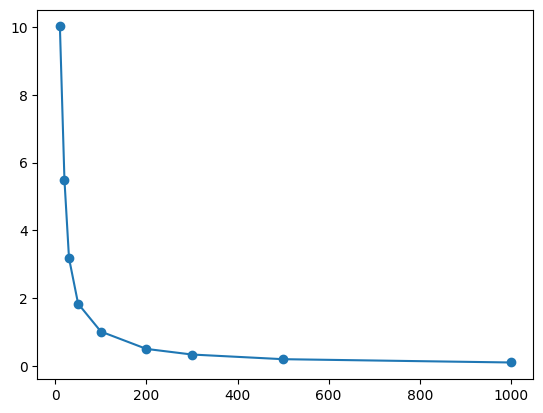

In [106]:
plt.plot(N_GENES, SUMs)
plt.scatter(N_GENES, SUMs, marker='o');

In [22]:
from data_simulations import (
    TissueCellTypes, 
    CellTypesProperties, 
    HybISS_Setup
)

# 2. Create the master "Tissue" (gene expression table)
print("Initializing tissue and experiment...")
tissue = TissueCellTypes()
tissue.generate_types_and_markers(
    n_genes=100, 
    n_cell_types=N_CELL_TYPES, 
    expected_level=100.0, 
    expected_std_level=20.0,
    # concentration=0.5
)

cell_type_df = tissue.make_pandas_df()

Initializing tissue and experiment...


<Axes: >

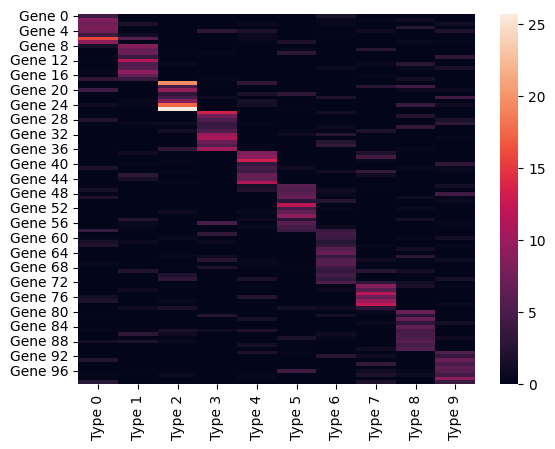

In [23]:
import seaborn as sns
sns.heatmap(cell_type_df)

In [20]:
FOLDER_NAME = 'scale_dataset/gs0.7_gvar0.3'
os.makedirs(FOLDER_NAME, exist_ok=True)
os.makedirs(f'{FOLDER_NAME}/data/', exist_ok=True)
os.makedirs(f'{FOLDER_NAME}/parameters/', exist_ok=True)
os.makedirs(f'{FOLDER_NAME}/ground_truths/', exist_ok=True)
cell_type_df.to_csv(f'{FOLDER_NAME}/parameters/cell_types.csv')

# 3. Create the "Cell Properties" object
# (This is the object your code was missing)
cell_props = CellTypesProperties(
    n_cell_types=N_CELL_TYPES,
    sizes=12,
    size_variation=0.2,
    anisotropy=1.5,
    anisotropy_variation=0.3,
    relative_rna_concentration=1.0,
    rna_concentration_variation=0.05
)

# 4. Create the "HybISS Experiment" simulator
hybISS = HybISS_Setup(
    tissue,
    genes_sensitivities=0.7,
    genes_sensitivities_variation=0.3,
    transfer_function=IdentityTransfer()
)

print("Ready to process tiles.")

Ready to process tiles.


In [24]:
# # --- 1. Generate the Global Master Tissue ---
# # (Make sure you applied the bug fix!)
# print("Generating global tissue... this may take a while.")
# tissue_slice.generate_global()
# tissue_slice.sample_labels() # Assign hard labels

# print(f"Generated {len(tissue_slice._cells_xy)} total cells.")

# # --- 2. Tile into 1000x1000 FOVs with 10% Overlap ---
# FOV_SIZE = 100
# OVERLAP = 0.10
# print(f"Tiling into {FOV_SIZE}px FOVs with {OVERLAP*100}% overlap...")
# fov_tiles = tissue_slice.tile_into_fovs(fov_size=FOV_SIZE, 
#                                         overlap_frac=OVERLAP)

# print(f"Created {len(fov_tiles)} FOV tiles.")

# # --- 3. Process Each Tile (Generate Dots, Save, etc.) ---
# # (Assuming you have `hybISS` and `cell_props` objects ready)

# for i, tile in tqdm.tqdm(enumerate(fov_tiles)):
#     tile_indices = tile['idx']
#     if len(tile_indices) == 0:
#         continue # Skip empty FOVs

#     # Get data for this FOV
#     fov_xy = tissue_slice._cells_xy[tile_indices]
#     fov_probs = tissue_slice._probs[tile_indices]
#     fov_onehot = tissue_slice._class_onehot[tile_indices]

#     # Create an FOV object
#     fov = FOV(cell_centroids=fov_xy, cell_probabilities=fov_probs)
#     fov.class_instance_one_hot = fov_onehot # Assign the pre-sampled labels
    
#     # Apply cell properties (size, rotation, etc.)
#     cell_props.apply(fov)
    
#     # Simulate the HybISS dots
#     hybISS.observe_dots(fov)
    
#     # Save the data
#     dots_df = hybISS.make_pandas_df()
#     cells_df = fov.make_pandas_df()
    
#     # (Add your saving logic here)
#     dots_df_XY = dots_df[['x', 'y', 'gene']]
#     dots_df_XY.to_csv(f"output2/data/dots_FOV{i:03d}.csv")
#     dots_df.to_csv(f"output2/ground_truths/dots_FOV{i:03d}.csv")
    
#     cells_df_XY = cells_df[['X', 'Y']].copy()
#     cells_df_XY.to_csv(f"output2/data/cell_centroids_FOV{i:03d}.csv")
#     cells_df.to_csv(f"output2/ground_truths/ground_truth_FOV{i:03d}.csv")
    
# print(f"Done processing all tiles.")

In [21]:
# --- 1. Generate the Global Master Tissue ---
print("Generating global tissue... this may take a while.")
tissue_slice.generate_global()
tissue_slice.sample_labels() # Assign hard labels

print(f"Generated {len(tissue_slice._cells_xy)} total cells.")

# --- 1b. NEW: Generate and Save Full Tissue Data (Global) ---
print("Generating global data for the full tissue slice...")

# Create one giant FOV object from the global data
global_fov = FOV(
    cell_centroids=tissue_slice._cells_xy,
    cell_probabilities=tissue_slice._probs
)
global_fov.class_instance_one_hot = tissue_slice._class_onehot

# Apply properties to all cells
print("Applying cell properties to global data...")
cell_props.apply(global_fov)

# Observe dots for all cells
print("Simulating dots for global data...")
hybISS.observe_dots(global_fov)

# Make the global dataframes
global_cells_df = global_fov.make_pandas_df()
global_dots_df = hybISS.make_pandas_df()

# Save them
print(f"Saving global data: {len(global_cells_df)} cells, {len(global_dots_df)} dots")
global_cells_df.to_csv(f"{FOLDER_NAME}/ground_truths/global_ground_truth_cells.csv")
global_dots_df.to_csv(f"{FOLDER_NAME}/ground_truths/global_ground_truth_dots.csv")

# Save the "data" versions (just XY)
global_cells_df[['X', 'Y']].to_csv(f"{FOLDER_NAME}/data/global_cell_centroids.csv")
global_dots_df[['x', 'y', 'gene']].to_csv(f"{FOLDER_NAME}/data/global_dots.csv")

print("Global data saved.")


# --- 2. MODIFIED: Tile into NON-OVERLAPPING FOVs ---
FOV_SIZE = 100
OVERLAP = 0.0  # <-- MODIFICATION: Set overlap to 0
print(f"Tiling into {FOV_SIZE}px NON-overlapping FOVs...")
fov_tiles = tissue_slice.tile_into_fovs(fov_size=FOV_SIZE, 
                                        overlap_frac=OVERLAP)

print(f"Created {len(fov_tiles)} non-overlapping FOV tiles.")

# --- 3. Process Each Tile (Generate Dots, Save, etc.) ---
# (This loop now processes non-overlapping tiles)
print("Processing and saving individual non-overlapping tiles...")
for i, tile in tqdm.tqdm(enumerate(fov_tiles)):
    tile_indices = tile['idx']
    if len(tile_indices) == 0:
        continue # Skip empty FOVs

    # Get data for this FOV
    fov_xy = tissue_slice._cells_xy[tile_indices]
    fov_probs = tissue_slice._probs[tile_indices]
    fov_onehot = tissue_slice._class_onehot[tile_indices]

    # Create an FOV object
    fov = FOV(cell_centroids=fov_xy, cell_probabilities=fov_probs)
    fov.class_instance_one_hot = fov_onehot # Assign the pre-sampled labels
    
    # Apply cell properties (size, rotation, etc.)
    cell_props.apply(fov)
    
    # Simulate the HybISS dots
    hybISS.observe_dots(fov)
    
    # Save the data
    dots_df = hybISS.make_pandas_df()
    cells_df = fov.make_pandas_df()
    
    # (Add your saving logic here)
    dots_df_XY = dots_df[['x', 'y', 'gene']]
    dots_df_XY.to_csv(f"{FOLDER_NAME}/data/dots_FOV{i:03d}.csv")
    dots_df.to_csv(f"{FOLDER_NAME}/ground_truths/dots_FOV{i:03d}.csv")
    
    cells_df_XY = cells_df[['X', 'Y']].copy()
    cells_df_XY.to_csv(f"{FOLDER_NAME}/data/cell_centroids_FOV{i:03d}.csv")
    cells_df.to_csv(f"{FOLDER_NAME}/ground_truths/ground_truth_FOV{i:03d}.csv")
    
print(f"Done processing all tiles.")

Generating global tissue... this may take a while.
Generated 15173 total cells.
Generating global data for the full tissue slice...
Applying cell properties to global data...
Simulating dots for global data...
Saving global data: 15173 cells, 1002441 dots
Global data saved.
Tiling into 100px NON-overlapping FOVs...
Created 144 non-overlapping FOV tiles.
Processing and saving individual non-overlapping tiles...


144it [00:03, 39.46it/s]

Done processing all tiles.


In [111]:
from data_simulations import (
    TissueCellTypes, 
    CellTypesProperties, 
    HybISS_Setup
)

N_genes = [10, 30, 50, 100, 200]
N_expected = [10, 30, 50, 100, 200]
N_std_expected = [3, 5, 10, 20, 40]

for i in range(len(N_genes)):
    # 2. Create the master "Tissue" (gene expression table)
    print("Initializing tissue and experiment...")
    tissue = TissueCellTypes()
    tissue.generate_types_and_markers(
        n_genes=N_genes[i],
        n_cell_types=N_CELL_TYPES, 
        expected_level=N_expected[i],
        expected_std_level=N_std_expected[i],
    )
    FOLDER_NAME = f'gene_sensetivity_number_datasets3/{N_genes[i]}g'
    os.makedirs(FOLDER_NAME, exist_ok=True)
    os.makedirs(f'{FOLDER_NAME}/data/', exist_ok=True)
    os.makedirs(f'{FOLDER_NAME}/parameters/', exist_ok=True)
    os.makedirs(f'{FOLDER_NAME}/ground_truths/', exist_ok=True)

    cell_type_df = tissue.make_pandas_df()
    cell_type_df.to_csv(f'{FOLDER_NAME}/parameters/cell_types.csv')

    # 3. Create the "Cell Properties" object
    # (This is the object your code was missing)
    cell_props = CellTypesProperties(
        n_cell_types=N_CELL_TYPES,
        sizes=12,
        size_variation=0.2,
        anisotropy=1.5,
        anisotropy_variation=0.3,
        relative_rna_concentration=1.0,
        rna_concentration_variation=0.05
    )

    # 4. Create the "HybISS Experiment" simulator
    hybISS = HybISS_Setup(
        tissue,
        genes_sensitivities=0.7,
        genes_sensitivities_variation=0.3,
        transfer_function=IdentityTransfer()
    )

    print("Ready to process tiles.")

    # --- 1. Generate the Global Master Tissue ---
    print("Generating global tissue... this may take a while.")
    tissue_slice.generate_global()
    tissue_slice.sample_labels() # Assign hard labels

    print(f"Generated {len(tissue_slice._cells_xy)} total cells.")

    # --- 1b. NEW: Generate and Save Full Tissue Data (Global) ---
    print("Generating global data for the full tissue slice...")

    # Create one giant FOV object from the global data
    global_fov = FOV(
        cell_centroids=tissue_slice._cells_xy,
        cell_probabilities=tissue_slice._probs
    )
    global_fov.class_instance_one_hot = tissue_slice._class_onehot

    # Apply properties to all cells
    print("Applying cell properties to global data...")
    cell_props.apply(global_fov)

    # Observe dots for all cells
    print("Simulating dots for global data...")
    hybISS.observe_dots(global_fov)

    # Make the global dataframes
    global_cells_df = global_fov.make_pandas_df()
    global_dots_df = hybISS.make_pandas_df()

    # Save them
    print(f"Saving global data: {len(global_cells_df)} cells, {len(global_dots_df)} dots")
    global_cells_df.to_csv(f"{FOLDER_NAME}/ground_truths/global_ground_truth_cells.csv")
    global_dots_df.to_csv(f"{FOLDER_NAME}/ground_truths/global_ground_truth_dots.csv")

    # Save the "data" versions (just XY)
    global_cells_df[['X', 'Y']].to_csv(f"{FOLDER_NAME}/data/global_cell_centroids.csv")
    global_dots_df[['x', 'y', 'gene']].to_csv(f"{FOLDER_NAME}/data/global_dots.csv")

    print("Global data saved.")


    # --- 2. MODIFIED: Tile into NON-OVERLAPPING FOVs ---
    FOV_SIZE = 100
    OVERLAP = 0.0  # <-- MODIFICATION: Set overlap to 0
    print(f"Tiling into {FOV_SIZE}px NON-overlapping FOVs...")
    fov_tiles = tissue_slice.tile_into_fovs(fov_size=FOV_SIZE, 
                                            overlap_frac=OVERLAP)

    print(f"Created {len(fov_tiles)} non-overlapping FOV tiles.")

    # --- 3. Process Each Tile (Generate Dots, Save, etc.) ---
    # (This loop now processes non-overlapping tiles)
    print("Processing and saving individual non-overlapping tiles...")
    for i, tile in tqdm.tqdm(enumerate(fov_tiles)):
        tile_indices = tile['idx']
        if len(tile_indices) == 0:
            continue # Skip empty FOVs

        # Get data for this FOV
        fov_xy = tissue_slice._cells_xy[tile_indices]
        fov_probs = tissue_slice._probs[tile_indices]
        fov_onehot = tissue_slice._class_onehot[tile_indices]

        # Create an FOV object
        fov = FOV(cell_centroids=fov_xy, cell_probabilities=fov_probs)
        fov.class_instance_one_hot = fov_onehot # Assign the pre-sampled labels
        
        # Apply cell properties (size, rotation, etc.)
        cell_props.apply(fov)
        
        # Simulate the HybISS dots
        hybISS.observe_dots(fov)
        
        # Save the data
        dots_df = hybISS.make_pandas_df()
        cells_df = fov.make_pandas_df()
        
        # (Add your saving logic here)
        dots_df_XY = dots_df[['x', 'y', 'gene']]
        dots_df_XY.to_csv(f"{FOLDER_NAME}/data/dots_FOV{i:03d}.csv")
        dots_df.to_csv(f"{FOLDER_NAME}/ground_truths/dots_FOV{i:03d}.csv")
        
        cells_df_XY = cells_df[['X', 'Y']].copy()
        cells_df_XY.to_csv(f"{FOLDER_NAME}/data/cell_centroids_FOV{i:03d}.csv")
        cells_df.to_csv(f"{FOLDER_NAME}/ground_truths/ground_truth_FOV{i:03d}.csv")
        
    print(f"Done processing all tiles.")

Initializing tissue and experiment...
Ready to process tiles.
Generating global tissue... this may take a while.
Generated 14747 total cells.
Generating global data for the full tissue slice...
Applying cell properties to global data...
Simulating dots for global data...
Saving global data: 14747 cells, 114517 dots
Global data saved.
Tiling into 100px NON-overlapping FOVs...
Created 144 non-overlapping FOV tiles.
Processing and saving individual non-overlapping tiles...


144it [00:00, 153.34it/s]


Done processing all tiles.
Initializing tissue and experiment...
Ready to process tiles.
Generating global tissue... this may take a while.
Generated 14989 total cells.
Generating global data for the full tissue slice...
Applying cell properties to global data...
Simulating dots for global data...
Saving global data: 14989 cells, 373697 dots
Global data saved.
Tiling into 100px NON-overlapping FOVs...
Created 144 non-overlapping FOV tiles.
Processing and saving individual non-overlapping tiles...


144it [00:01, 76.70it/s]


Done processing all tiles.
Initializing tissue and experiment...
Ready to process tiles.
Generating global tissue... this may take a while.
Generated 14946 total cells.
Generating global data for the full tissue slice...
Applying cell properties to global data...
Simulating dots for global data...
Saving global data: 14946 cells, 497969 dots
Global data saved.
Tiling into 100px NON-overlapping FOVs...
Created 144 non-overlapping FOV tiles.
Processing and saving individual non-overlapping tiles...


...

Done processing all tiles.
Initializing tissue and experiment...
Ready to process tiles.
Generating global tissue... this may take a while.
Generated 15028 total cells.
Generating global data for the full tissue slice...
Applying cell properties to global data...
Simulating dots for global data...
Saving global data: 15028 cells, 1108899 dots
Global data saved.
Tiling into 100px NON-overlapping FOVs...
Created 144 non-overlapping FOV tiles.
Processing and saving individual non-overlapping tiles...


144it [00:04, 34.90it/s]


Done processing all tiles.
Initializing tissue and experiment...
Ready to process tiles.
Generating global tissue... this may take a while.
Generated 15047 total cells.
Generating global data for the full tissue slice...
Applying cell properties to global data...
Simulating dots for global data...
Saving global data: 15047 cells, 2187507 dots
Global data saved.
Tiling into 100px NON-overlapping FOVs...
Created 144 non-overlapping FOV tiles.
Processing and saving individual non-overlapping tiles...


144it [00:08, 17.11it/s]

Done processing all tiles.


In [8]:
from data_simulations import (
    TissueCellTypes, 
    CellTypesProperties, 
    HybISS_Setup
)

SPARSITY_LEVELS = [0.1, 0.3, 0.5, 0.7, 1.0]
SPARSITY_VAR_LEVELS = [0.005, 0.015, 0.025, 0.035, 0.05]
N_CELL_TYPES = 10

for i in range(len(SPARSITY_LEVELS)):
    # 2. Create the master "Tissue" (gene expression table)
    print("Initializing tissue and experiment...")
    tissue = TissueCellTypes()
    tissue.generate_types_and_markers(
        n_genes=50,
        n_cell_types=N_CELL_TYPES, 
        expected_level=50,
        expected_std_level=5,
    )
    FOLDER_NAME = f'gene_sensetivity_sparsity_datasets/{SPARSITY_LEVELS[i]}'
    os.makedirs(FOLDER_NAME, exist_ok=True)
    os.makedirs(f'{FOLDER_NAME}/data/', exist_ok=True)
    os.makedirs(f'{FOLDER_NAME}/parameters/', exist_ok=True)
    os.makedirs(f'{FOLDER_NAME}/ground_truths/', exist_ok=True)

    cell_type_df = tissue.make_pandas_df()
    cell_type_df.to_csv(f'{FOLDER_NAME}/parameters/cell_types.csv')

    # 3. Create the "Cell Properties" object
    # (This is the object your code was missing)
    cell_props = CellTypesProperties(
        n_cell_types=N_CELL_TYPES,
        sizes=12,
        size_variation=0.2,
        anisotropy=1.5,
        anisotropy_variation=0.3,
        relative_rna_concentration=SPARSITY_LEVELS[i],
        rna_concentration_variation=SPARSITY_VAR_LEVELS[i],
    )

    # 4. Create the "HybISS Experiment" simulator
    hybISS = HybISS_Setup(
        tissue,
        genes_sensitivities=0.7,
        genes_sensitivities_variation=0.3,
        transfer_function=IdentityTransfer()
    )

    print("Ready to process tiles.")

    # --- 1. Generate the Global Master Tissue ---
    print("Generating global tissue... this may take a while.")
    tissue_slice.generate_global()
    tissue_slice.sample_labels() # Assign hard labels

    print(f"Generated {len(tissue_slice._cells_xy)} total cells.")

    # --- 1b. NEW: Generate and Save Full Tissue Data (Global) ---
    print("Generating global data for the full tissue slice...")

    # Create one giant FOV object from the global data
    global_fov = FOV(
        cell_centroids=tissue_slice._cells_xy,
        cell_probabilities=tissue_slice._probs
    )
    global_fov.class_instance_one_hot = tissue_slice._class_onehot

    # Apply properties to all cells
    print("Applying cell properties to global data...")
    cell_props.apply(global_fov)

    # Observe dots for all cells
    print("Simulating dots for global data...")
    hybISS.observe_dots(global_fov)

    # Make the global dataframes
    global_cells_df = global_fov.make_pandas_df()
    global_dots_df = hybISS.make_pandas_df()

    # Save them
    print(f"Saving global data: {len(global_cells_df)} cells, {len(global_dots_df)} dots")
    global_cells_df.to_csv(f"{FOLDER_NAME}/ground_truths/global_ground_truth_cells.csv")
    global_dots_df.to_csv(f"{FOLDER_NAME}/ground_truths/global_ground_truth_dots.csv")

    # Save the "data" versions (just XY)
    global_cells_df[['X', 'Y']].to_csv(f"{FOLDER_NAME}/data/global_cell_centroids.csv")
    global_dots_df[['x', 'y', 'gene']].to_csv(f"{FOLDER_NAME}/data/global_dots.csv")

    print("Global data saved.")


    # --- 2. MODIFIED: Tile into NON-OVERLAPPING FOVs ---
    FOV_SIZE = 100
    OVERLAP = 0.0  # <-- MODIFICATION: Set overlap to 0
    print(f"Tiling into {FOV_SIZE}px NON-overlapping FOVs...")
    fov_tiles = tissue_slice.tile_into_fovs(fov_size=FOV_SIZE, 
                                            overlap_frac=OVERLAP)

    print(f"Created {len(fov_tiles)} non-overlapping FOV tiles.")

    # --- 3. Process Each Tile (Generate Dots, Save, etc.) ---
    # (This loop now processes non-overlapping tiles)
    print("Processing and saving individual non-overlapping tiles...")
    for i, tile in tqdm.tqdm(enumerate(fov_tiles)):
        tile_indices = tile['idx']
        if len(tile_indices) == 0:
            continue # Skip empty FOVs

        # Get data for this FOV
        fov_xy = tissue_slice._cells_xy[tile_indices]
        fov_probs = tissue_slice._probs[tile_indices]
        fov_onehot = tissue_slice._class_onehot[tile_indices]

        # Create an FOV object
        fov = FOV(cell_centroids=fov_xy, cell_probabilities=fov_probs)
        fov.class_instance_one_hot = fov_onehot # Assign the pre-sampled labels
        
        # Apply cell properties (size, rotation, etc.)
        cell_props.apply(fov)
        
        # Simulate the HybISS dots
        hybISS.observe_dots(fov)
        
        # Save the data
        dots_df = hybISS.make_pandas_df()
        cells_df = fov.make_pandas_df()
        
        # (Add your saving logic here)
        dots_df_XY = dots_df[['x', 'y', 'gene']]
        dots_df_XY.to_csv(f"{FOLDER_NAME}/data/dots_FOV{i:03d}.csv")
        dots_df.to_csv(f"{FOLDER_NAME}/ground_truths/dots_FOV{i:03d}.csv")
        
        cells_df_XY = cells_df[['X', 'Y']].copy()
        cells_df_XY.to_csv(f"{FOLDER_NAME}/data/cell_centroids_FOV{i:03d}.csv")
        cells_df.to_csv(f"{FOLDER_NAME}/ground_truths/ground_truth_FOV{i:03d}.csv")
        
    print(f"Done processing all tiles.")

Initializing tissue and experiment...
Ready to process tiles.
Generating global tissue... this may take a while.
Generated 15461 total cells.
Generating global data for the full tissue slice...
Applying cell properties to global data...
Simulating dots for global data...
Saving global data: 15461 cells, 46221 dots
Global data saved.
Tiling into 100px NON-overlapping FOVs...
Created 144 non-overlapping FOV tiles.
Processing and saving individual non-overlapping tiles...


144it [00:00, 182.36it/s]


Done processing all tiles.
Initializing tissue and experiment...
Ready to process tiles.
Generating global tissue... this may take a while.
Generated 15972 total cells.
Generating global data for the full tissue slice...
Applying cell properties to global data...
Simulating dots for global data...
Saving global data: 15972 cells, 163227 dots
Global data saved.
Tiling into 100px NON-overlapping FOVs...
Created 144 non-overlapping FOV tiles.
Processing and saving individual non-overlapping tiles...


144it [00:01, 125.45it/s]


Done processing all tiles.
Initializing tissue and experiment...
Ready to process tiles.
Generating global tissue... this may take a while.
Generated 15447 total cells.
Generating global data for the full tissue slice...
Applying cell properties to global data...
Simulating dots for global data...
Saving global data: 15447 cells, 256335 dots
Global data saved.
Tiling into 100px NON-overlapping FOVs...
Created 144 non-overlapping FOV tiles.
Processing and saving individual non-overlapping tiles...


...

Done processing all tiles.
Initializing tissue and experiment...
Ready to process tiles.
Generating global tissue... this may take a while.
Generated 15689 total cells.
Generating global data for the full tissue slice...
Applying cell properties to global data...
Simulating dots for global data...
Saving global data: 15689 cells, 362178 dots
Global data saved.
Tiling into 100px NON-overlapping FOVs...
Created 144 non-overlapping FOV tiles.
Processing and saving individual non-overlapping tiles...


144it [00:01, 78.23it/s]


Done processing all tiles.
Initializing tissue and experiment...
Ready to process tiles.
Generating global tissue... this may take a while.
Generated 15807 total cells.
Generating global data for the full tissue slice...
Applying cell properties to global data...
Simulating dots for global data...
Saving global data: 15807 cells, 513318 dots
Global data saved.
Tiling into 100px NON-overlapping FOVs...
Created 144 non-overlapping FOV tiles.
Processing and saving individual non-overlapping tiles...


144it [00:02, 62.85it/s]

Done processing all tiles.


In [ ]:
from data_simulations import (
    TissueCellTypes, 
    CellTypesProperties, 
    HybISS_Setup
)

GENE_SENSITIVITES = [0.03, 0.1, 0.4, 0.7, 1.0]
GENE_SENSITIVITES_VAR = [x/2.5 for x in GENE_SENSITIVITES]
N_CELL_TYPES = 10

for i in range(len(GENE_SENSITIVITES)):
    # 2. Create the master "Tissue" (gene expression table)
    print("Initializing tissue and experiment...")
    tissue = TissueCellTypes()
    tissue.generate_types_and_markers(
        n_genes=100,
        n_cell_types=N_CELL_TYPES, 
        expected_level=100,
        expected_std_level=10,
    )
    FOLDER_NAME = f'gene_sensetivity_geneSparsity_datasets/{GENE_SENSITIVITES[i]}'
    os.makedirs(FOLDER_NAME, exist_ok=True)
    os.makedirs(f'{FOLDER_NAME}/data/', exist_ok=True)
    os.makedirs(f'{FOLDER_NAME}/parameters/', exist_ok=True)
    os.makedirs(f'{FOLDER_NAME}/ground_truths/', exist_ok=True)

    cell_type_df = tissue.make_pandas_df()
    cell_type_df.to_csv(f'{FOLDER_NAME}/parameters/cell_types.csv')

    # 3. Create the "Cell Properties" object
    cell_props = CellTypesProperties(
        n_cell_types=N_CELL_TYPES,
        sizes=12,
        size_variation=0.2,
        anisotropy=1.5,
        anisotropy_variation=0.3,
        relative_rna_concentration=1.0,
        rna_concentration_variation=0.05,
    )

    # 4. Create the "HybISS Experiment" simulator
    hybISS = HybISS_Setup(
        tissue,
        genes_sensitivities=GENE_SENSITIVITES[i],
        genes_sensitivities_variation=GENE_SENSITIVITES_VAR[i],
        transfer_function=IdentityTransfer()
    )

    print("Ready to process tiles.")

    # --- 1. Generate the Global Master Tissue ---
    print("Generating global tissue... this may take a while.")
    tissue_slice.generate_global()
    tissue_slice.sample_labels() # Assign hard labels

    print(f"Generated {len(tissue_slice._cells_xy)} total cells.")

    # --- 1b. NEW: Generate and Save Full Tissue Data (Global) ---
    print("Generating global data for the full tissue slice...")

    # Create one giant FOV object from the global data
    global_fov = FOV(
        cell_centroids=tissue_slice._cells_xy,
        cell_probabilities=tissue_slice._probs
    )
    global_fov.class_instance_one_hot = tissue_slice._class_onehot

    # Apply properties to all cells
    print("Applying cell properties to global data...")
    cell_props.apply(global_fov)

    # Observe dots for all cells
    print("Simulating dots for global data...")
    hybISS.observe_dots(global_fov)

    # Make the global dataframes
    global_cells_df = global_fov.make_pandas_df()
    global_dots_df = hybISS.make_pandas_df()

    # Save them
    print(f"Saving global data: {len(global_cells_df)} cells, {len(global_dots_df)} dots")
    global_cells_df.to_csv(f"{FOLDER_NAME}/ground_truths/global_ground_truth_cells.csv")
    global_dots_df.to_csv(f"{FOLDER_NAME}/ground_truths/global_ground_truth_dots.csv")

    # Save the "data" versions (just XY)
    global_cells_df[['X', 'Y']].to_csv(f"{FOLDER_NAME}/data/global_cell_centroids.csv")
    global_dots_df[['x', 'y', 'gene']].to_csv(f"{FOLDER_NAME}/data/global_dots.csv")

    print("Global data saved.")


    # --- 2. MODIFIED: Tile into NON-OVERLAPPING FOVs ---
    FOV_SIZE = 100
    OVERLAP = 0.0  # <-- MODIFICATION: Set overlap to 0
    print(f"Tiling into {FOV_SIZE}px NON-overlapping FOVs...")
    fov_tiles = tissue_slice.tile_into_fovs(fov_size=FOV_SIZE, 
                                            overlap_frac=OVERLAP)

    print(f"Created {len(fov_tiles)} non-overlapping FOV tiles.")

    # --- 3. Process Each Tile (Generate Dots, Save, etc.) ---
    # (This loop now processes non-overlapping tiles)
    print("Processing and saving individual non-overlapping tiles...")
    for i, tile in tqdm.tqdm(enumerate(fov_tiles)):
        tile_indices = tile['idx']
        if len(tile_indices) == 0:
            continue # Skip empty FOVs

        # Get data for this FOV
        fov_xy = tissue_slice._cells_xy[tile_indices]
        fov_probs = tissue_slice._probs[tile_indices]
        fov_onehot = tissue_slice._class_onehot[tile_indices]

        # Create an FOV object
        fov = FOV(cell_centroids=fov_xy, cell_probabilities=fov_probs)
        fov.class_instance_one_hot = fov_onehot # Assign the pre-sampled labels
        
        # Apply cell properties (size, rotation, etc.)
        cell_props.apply(fov)
        
        # Simulate the HybISS dots
        hybISS.observe_dots(fov)
        
        # Save the data
        dots_df = hybISS.make_pandas_df()
        cells_df = fov.make_pandas_df()
        
        # (Add your saving logic here)
        dots_df_XY = dots_df[['x', 'y', 'gene']]
        dots_df_XY.to_csv(f"{FOLDER_NAME}/data/dots_FOV{i:03d}.csv")
        dots_df.to_csv(f"{FOLDER_NAME}/ground_truths/dots_FOV{i:03d}.csv")
        
        cells_df_XY = cells_df[['X', 'Y']].copy()
        cells_df_XY.to_csv(f"{FOLDER_NAME}/data/cell_centroids_FOV{i:03d}.csv")
        cells_df.to_csv(f"{FOLDER_NAME}/ground_truths/ground_truth_FOV{i:03d}.csv")
        
    print(f"Done processing all tiles.")

Initializing tissue and experiment...
Ready to process tiles.
Generating global tissue... this may take a while.
Generated 15258 total cells.
Generating global data for the full tissue slice...
Applying cell properties to global data...
Simulating dots for global data...
Saving global data: 15258 cells, 44805 dots
Global data saved.
Tiling into 100px NON-overlapping FOVs...
Created 144 non-overlapping FOV tiles.
Processing and saving individual non-overlapping tiles...


144it [00:00, 161.92it/s]


Done processing all tiles.
Initializing tissue and experiment...
Ready to process tiles.
Generating global tissue... this may take a while.
Generated 15406 total cells.
Generating global data for the full tissue slice...
Applying cell properties to global data...
Simulating dots for global data...
Saving global data: 15406 cells, 151929 dots
Global data saved.
Tiling into 100px NON-overlapping FOVs...
Created 144 non-overlapping FOV tiles.
Processing and saving individual non-overlapping tiles...


144it [00:01, 110.31it/s]


Done processing all tiles.
Initializing tissue and experiment...
Ready to process tiles.
Generating global tissue... this may take a while.
Generated 15777 total cells.
Generating global data for the full tissue slice...
Applying cell properties to global data...
Simulating dots for global data...
Saving global data: 15777 cells, 614085 dots
Global data saved.
Tiling into 100px NON-overlapping FOVs...
Created 144 non-overlapping FOV tiles.
Processing and saving individual non-overlapping tiles...


...

Done processing all tiles.
Initializing tissue and experiment...
Ready to process tiles.
Generating global tissue... this may take a while.
Generated 15592 total cells.
Generating global data for the full tissue slice...
Applying cell properties to global data...
Simulating dots for global data...
Saving global data: 15592 cells, 1045726 dots
Global data saved.
Tiling into 100px NON-overlapping FOVs...
Created 144 non-overlapping FOV tiles.
Processing and saving individual non-overlapping tiles...


144it [00:03, 37.44it/s]


Done processing all tiles.
Initializing tissue and experiment...
Ready to process tiles.
Generating global tissue... this may take a while.
Generated 15447 total cells.
Generating global data for the full tissue slice...
Applying cell properties to global data...
Simulating dots for global data...
Saving global data: 15447 cells, 1574466 dots
Global data saved.
Tiling into 100px NON-overlapping FOVs...
Created 144 non-overlapping FOV tiles.
Processing and saving individual non-overlapping tiles...


144it [00:05, 26.59it/s]

Done processing all tiles.


In [9]:
from data_simulations import (
    TissueCellTypes, 
    CellTypesProperties, 
    HybISS_Setup
)

GENE_SENSITIVITES = [0.03, 0.1, 0.4, 0.7, 1.0]
GENE_SENSITIVITES_VAR = [x/2.5 for x in GENE_SENSITIVITES]
EXPECTED_COUNTS = [10, 20, 50, 100, 200]
EXPECTED_COUNTS_VAR = [x/4 for x in EXPECTED_COUNTS]
N_CELL_TYPES = 10

for i in range(len(GENE_SENSITIVITES)):
    for k in range(len(EXPECTED_COUNTS)):
        # 2. Create the master "Tissue" (gene expression table)
        print("Initializing tissue and experiment...")
        tissue = TissueCellTypes()
        tissue.generate_types_and_markers(
            n_genes=100,
            n_cell_types=N_CELL_TYPES, 
            expected_level=EXPECTED_COUNTS[k],
            expected_std_level=EXPECTED_COUNTS_VAR[k],
        )
        FOLDER_NAME = f'gene_sensetivity_expected_counts_datasets/gs{GENE_SENSITIVITES[i]}_expcnt{EXPECTED_COUNTS[k]}'
        os.makedirs(FOLDER_NAME, exist_ok=True)
        os.makedirs(f'{FOLDER_NAME}/data/', exist_ok=True)
        os.makedirs(f'{FOLDER_NAME}/parameters/', exist_ok=True)
        os.makedirs(f'{FOLDER_NAME}/ground_truths/', exist_ok=True)

        cell_type_df = tissue.make_pandas_df()
        cell_type_df.to_csv(f'{FOLDER_NAME}/parameters/cell_types.csv')

        # 3. Create the "Cell Properties" object
        # (This is the object your code was missing)
        cell_props = CellTypesProperties(
            n_cell_types=N_CELL_TYPES,
            sizes=12,
            size_variation=0.2,
            anisotropy=1.5,
            anisotropy_variation=0.3,
            relative_rna_concentration=1.0,
            rna_concentration_variation=0.05,
        )

        # 4. Create the "HybISS Experiment" simulator
        hybISS = HybISS_Setup(
            tissue,
            genes_sensitivities=GENE_SENSITIVITES[i],
            genes_sensitivities_variation=GENE_SENSITIVITES_VAR[i],
            transfer_function=IdentityTransfer()
        )

        print("Ready to process tiles.")

        # --- 1. Generate the Global Master Tissue ---
        print("Generating global tissue... this may take a while.")
        tissue_slice.generate_global()
        tissue_slice.sample_labels() # Assign hard labels

        print(f"Generated {len(tissue_slice._cells_xy)} total cells.")

        # --- 1b. NEW: Generate and Save Full Tissue Data (Global) ---
        print("Generating global data for the full tissue slice...")

        # Create one giant FOV object from the global data
        global_fov = FOV(
            cell_centroids=tissue_slice._cells_xy,
            cell_probabilities=tissue_slice._probs
        )
        global_fov.class_instance_one_hot = tissue_slice._class_onehot

        # Apply properties to all cells
        print("Applying cell properties to global data...")
        cell_props.apply(global_fov)

        # Observe dots for all cells
        print("Simulating dots for global data...")
        hybISS.observe_dots(global_fov)

        # Make the global dataframes
        global_cells_df = global_fov.make_pandas_df()
        global_dots_df = hybISS.make_pandas_df()

        # Save them
        print(f"Saving global data: {len(global_cells_df)} cells, {len(global_dots_df)} dots")
        global_cells_df.to_csv(f"{FOLDER_NAME}/ground_truths/global_ground_truth_cells.csv")
        global_dots_df.to_csv(f"{FOLDER_NAME}/ground_truths/global_ground_truth_dots.csv")

        # Save the "data" versions (just XY)
        global_cells_df[['X', 'Y']].to_csv(f"{FOLDER_NAME}/data/global_cell_centroids.csv")
        global_dots_df[['x', 'y', 'gene']].to_csv(f"{FOLDER_NAME}/data/global_dots.csv")

        print("Global data saved.")


        # --- 2. MODIFIED: Tile into NON-OVERLAPPING FOVs ---
        FOV_SIZE = 100
        OVERLAP = 0.0  # <-- MODIFICATION: Set overlap to 0
        print(f"Tiling into {FOV_SIZE}px NON-overlapping FOVs...")
        fov_tiles = tissue_slice.tile_into_fovs(fov_size=FOV_SIZE, 
                                                overlap_frac=OVERLAP)

        print(f"Created {len(fov_tiles)} non-overlapping FOV tiles.")

        # --- 3. Process Each Tile (Generate Dots, Save, etc.) ---
        # (This loop now processes non-overlapping tiles)
        print("Processing and saving individual non-overlapping tiles...")
        for t, tile in tqdm.tqdm(enumerate(fov_tiles)):
            tile_indices = tile['idx']
            if len(tile_indices) == 0:
                continue # Skip empty FOVs

            # Get data for this FOV
            fov_xy = tissue_slice._cells_xy[tile_indices]
            fov_probs = tissue_slice._probs[tile_indices]
            fov_onehot = tissue_slice._class_onehot[tile_indices]

            # Create an FOV object
            fov = FOV(cell_centroids=fov_xy, cell_probabilities=fov_probs)
            fov.class_instance_one_hot = fov_onehot # Assign the pre-sampled labels
            
            # Apply cell properties (size, rotation, etc.)
            cell_props.apply(fov)
            
            # Simulate the HybISS dots
            hybISS.observe_dots(fov)
            
            # Save the data
            dots_df = hybISS.make_pandas_df()
            cells_df = fov.make_pandas_df()
            
            # (Add your saving logic here)
            dots_df_XY = dots_df[['x', 'y', 'gene']]
            dots_df_XY.to_csv(f"{FOLDER_NAME}/data/dots_FOV{t:03d}.csv")
            dots_df.to_csv(f"{FOLDER_NAME}/ground_truths/dots_FOV{t:03d}.csv")
            
            cells_df_XY = cells_df[['X', 'Y']].copy()
            cells_df_XY.to_csv(f"{FOLDER_NAME}/data/cell_centroids_FOV{t:03d}.csv")
            cells_df.to_csv(f"{FOLDER_NAME}/ground_truths/ground_truth_FOV{t:03d}.csv")
            
        print(f"Done processing all tiles.")

Initializing tissue and experiment...
Ready to process tiles.
Generating global tissue... this may take a while.
Generated 15536 total cells.
Generating global data for the full tissue slice...
Applying cell properties to global data...
Simulating dots for global data...
Saving global data: 15536 cells, 4655 dots
Global data saved.
Tiling into 100px NON-overlapping FOVs...
Created 144 non-overlapping FOV tiles.
Processing and saving individual non-overlapping tiles...


144it [00:01, 136.70it/s]


Done processing all tiles.
Initializing tissue and experiment...
Ready to process tiles.
Generating global tissue... this may take a while.
Generated 15736 total cells.
Generating global data for the full tissue slice...
Applying cell properties to global data...
Simulating dots for global data...
Saving global data: 15736 cells, 9028 dots
Global data saved.
Tiling into 100px NON-overlapping FOVs...
Created 144 non-overlapping FOV tiles.
Processing and saving individual non-overlapping tiles...


144it [00:01, 125.30it/s]


Done processing all tiles.
Initializing tissue and experiment...
Ready to process tiles.
Generating global tissue... this may take a while.
Generated 15612 total cells.
Generating global data for the full tissue slice...
Applying cell properties to global data...
Simulating dots for global data...
Saving global data: 15612 cells, 23476 dots
Global data saved.
Tiling into 100px NON-overlapping FOVs...
Created 144 non-overlapping FOV tiles.
Processing and saving individual non-overlapping tiles...


...

Done processing all tiles.
Initializing tissue and experiment...
Ready to process tiles.
Generating global tissue... this may take a while.
Generated 15862 total cells.
Generating global data for the full tissue slice...
Applying cell properties to global data...
Simulating dots for global data...
Saving global data: 15862 cells, 1699033 dots
Global data saved.
Tiling into 100px NON-overlapping FOVs...
Created 144 non-overlapping FOV tiles.
Processing and saving individual non-overlapping tiles...


144it [00:08, 17.71it/s]


Done processing all tiles.
Initializing tissue and experiment...
Ready to process tiles.
Generating global tissue... this may take a while.
Generated 15498 total cells.
Generating global data for the full tissue slice...
Applying cell properties to global data...
Simulating dots for global data...
Saving global data: 15498 cells, 3221171 dots
Global data saved.
Tiling into 100px NON-overlapping FOVs...
Created 144 non-overlapping FOV tiles.
Processing and saving individual non-overlapping tiles...


144it [00:14, 10.07it/s]

Done processing all tiles.


##### Gene sensitivity level summary

0.3, 0.3: Saving global data: 15368 cells, 43640 dots
0.3, 0.5: Saving global data: 15519 cells, 60052 dots

0.5, 0.1: Saving global data: 15158 cells, 71563 dots
0.5, 0.3: Saving global data: 15472 cells, 80361 dots
0.5, 0.5: Saving global data: 15625 cells, 96798 dots

0.7, 0.1: Saving global data: 15345 cells, 107181 dots
0.7, 0.3: Saving global data: 15061 cells, 94547 dots
0.7, 0.5: Saving global data: 15106 cells, 116566 dots

1.0, 0.1: Saving global data: 15522 cells, 146265 dots
1.0, 0.3: Saving global data: 15371 cells, 172886 dots
1.0, 0.5: Saving global data: 15553 cells, 155081 dots

##### Gene sensitivity number summary

genes_sensitivities=0.7,
genes_sensitivities_variation=0.3,
expected_level=10.0, 
expected_std_level=3.0

-------------
10 genes: Saving global data: 15567 cells, 119711 dots
30 genes: Saving global data: 15139 cells, 122136 dots
50 genes: Saving global data: 14906 cells, 109088 dots
100 genes: Saving global data: 15290 cells, 113825 dots
200 genes: Saving global data: 15200 cells, 108850 dots

Mapping cell types to colors...
Plotting full tissue slice...


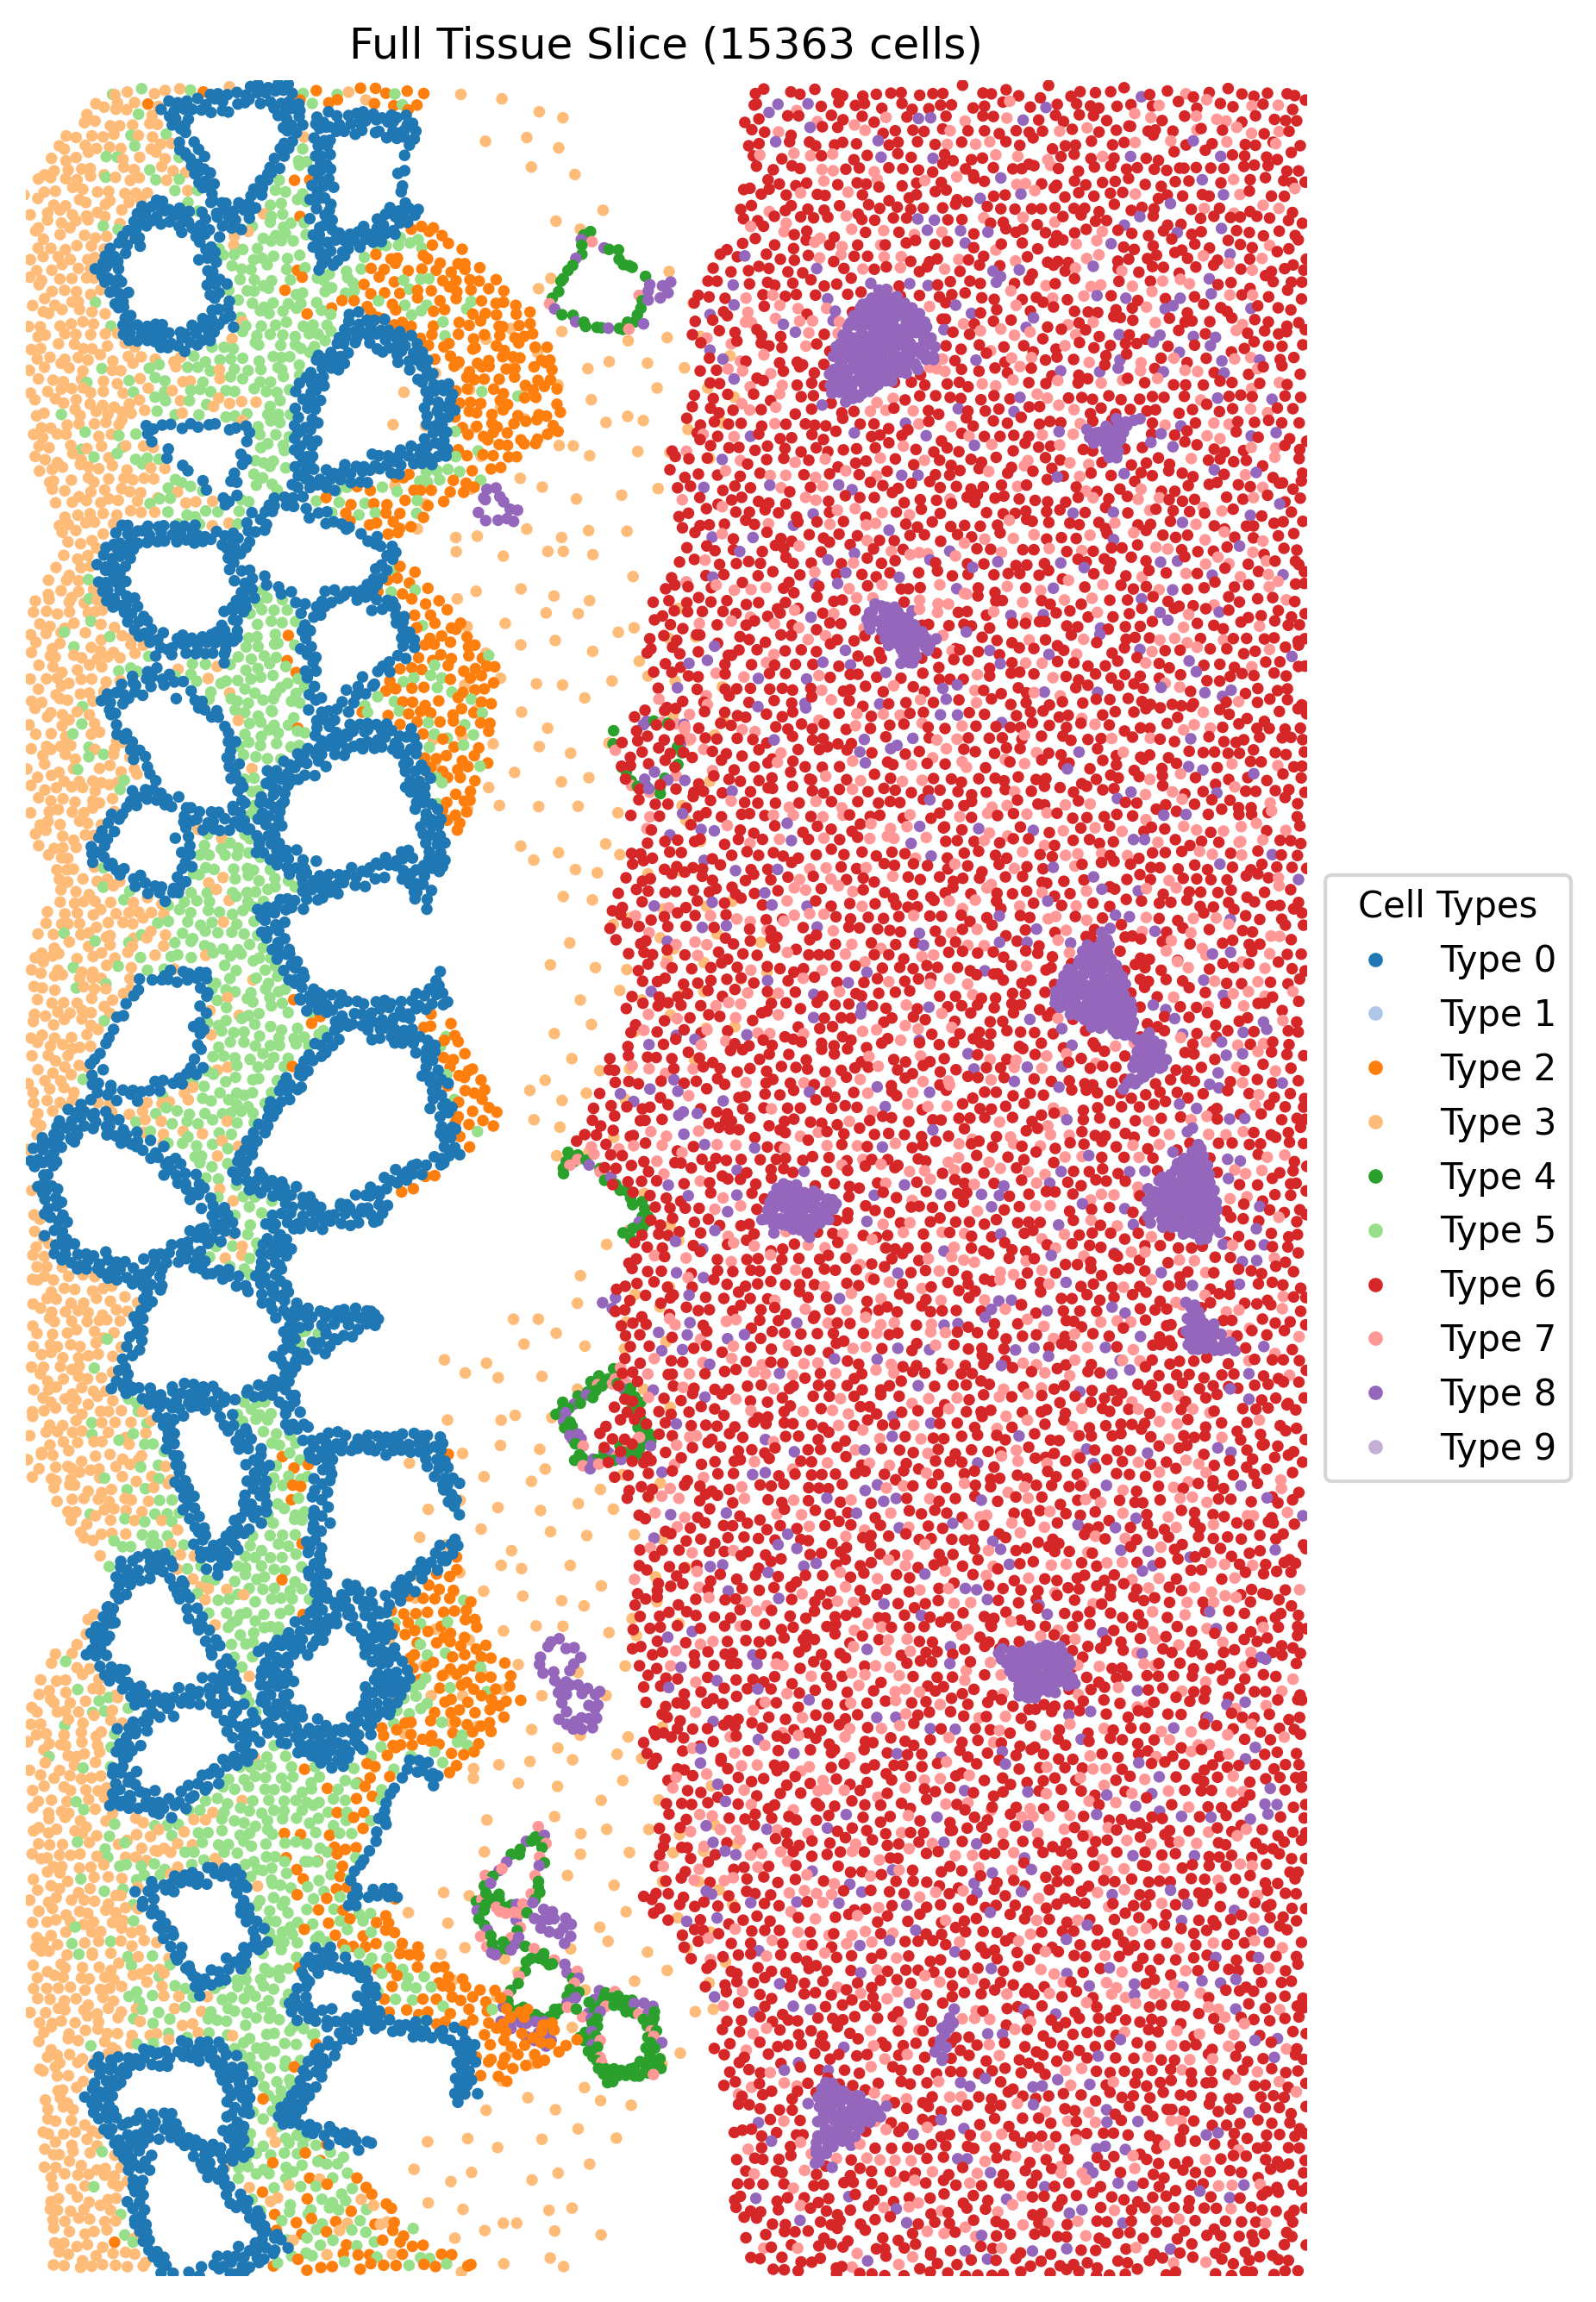

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# --- 1. Get the global cell types and colors ---
# (We only need to do this once)
print("Mapping cell types to colors...")
# Get the integer class ID for each cell
cell_types = np.argmax(tissue_slice._class_onehot, axis=1)
# Map each class ID to its color from the cell_props object
colors = [cell_props.colordict[c] for c in cell_types]

# --- 2. Create the main plot ---
print("Plotting full tissue slice...")
fig, ax = plt.subplots(figsize=(12, 9), dpi=300)
ax.scatter(
    tissue_slice._cells_xy[:, 0],
    tissue_slice._cells_xy[:, 1],
    c=colors,
    s=5,  # Use a small marker size for dense plots
    rasterized=True # Speeds up rendering for millions of points
)

# --- 3. Add tile outlines ---
# for tile in fov_tiles:
#     x0, y0, x1, y1 = tile['bbox']
#     rect = patches.Rectangle(
#         (x0, y0),
#         FOV_SIZE,
#         FOV_SIZE,
#         linewidth=0.5,
#         edgecolor='r',
#         facecolor='none',
#         alpha=0.5
#     )
#     ax.add_patch(rect)

# --- 4. Create a custom legend ---
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', 
               label=f"Type {key}",
               markerfacecolor=color, markersize=5)
    for key, color in cell_props.colordict.items()
    if key < N_CELL_TYPES # Only show types we used
]
ax.legend(handles=legend_elements, title="Cell Types", loc='center left', bbox_to_anchor=(1, 0.5))

# --- 5. Clean up and show ---
ax.set_title(f"Full Tissue Slice ({len(tissue_slice._cells_xy)} cells)")
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.set_xlim(0, GLOBAL_WIDTH)
ax.set_ylim(0, GLOBAL_HEIGHT)
ax.set_aspect('equal')
ax.invert_yaxis() # Put (0,0) at the top-left, like an image
ax.set_axis_off()
plt.tight_layout()
plt.show()